In [62]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [63]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [64]:
FIT = FitSpectrum()
DP = DP()

dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/0315_dps_test.fits')
ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list(), subtype_filter='QSO')
print('Total number of spectra:', len(ALL_SPECTRA.targetID))

Data loading and processing took 3.79 seconds.
Total number of spectra: 25671


In [74]:
dps_df.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,NII6583_SNR,SII6716_SNR,SII6731_SNR,BPT_1COMP,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.190807,-78.605568,50.497227,30.429682,...,3.326572,-1.000000,-1.000000,256,256,256,512,0.303909,-0.573267,2
1,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,113.683365,-61.165855,41.490192,69.213898,...,5.204332,-1.000000,-1.000000,256,256,256,512,-1.270763,-2.077943,1
2,39627739380058467,177.097977,-1.888290,0.123931,10.402426,1.031611,88.310776,-28.034325,30.202028,51.832150,...,7.630068,4.604237,3.504211,256,256,256,512,0.006628,-0.577312,3
3,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,73.980766,-94.167976,57.098171,51.152435,...,3.775856,-1.000000,-1.000000,256,256,256,512,-0.202920,-1.160233,2
4,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,87.747307,-73.973824,38.576229,50.498489,...,14.727792,8.114503,5.407719,1,1,1,2,0.253700,0.314512,5


In [66]:
# ALL_SPECTRA = ALL_SPECTRA.shrink_dataset(10)
# print('Number of spectra after shrinking:', len(ALL_SPECTRA.targetID))

In [67]:
ALL_SPECTRA.df.head()

,TARGETID,RA,DEC,Z,SPECTYPE,LOGM,LOGSFR
0,39627739380056564,177.019312,-1.965308,0.323187,GALAXY,10.452706,0.941032
1,39627739380057506,177.058476,-1.984356,0.102379,GALAXY,10.324258,-0.880754
2,39627739380058467,177.097982,-1.888290,0.123931,GALAXY,10.402426,1.031611
3,39627739380060210,177.177947,-1.988386,0.238389,GALAXY,10.496312,0.039087
4,39627739380061198,177.216425,-1.948593,0.103277,GALAXY,9.514435,0.903058


In [89]:
dps_df[dps_df['TARGETID'] == 39627776260572546]

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,NII6583_SNR,SII6716_SNR,SII6731_SNR,BPT_1COMP,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count
11695,39627776260572546,215.306091,-0.466594,0.101483,10.969656,0.86478,122.164696,-95.601189,141.547867,69.618546,...,9.114138,4.590575,3.389955,4,1,16,17,0.503665,-0.269118,3


In [90]:
test_idx = 11695
test_id = ALL_SPECTRA.df.iloc[test_idx]["TARGETID"]
# test_id = 39627776260572546
print(f'TARGETID: {test_id}')
lam = desi_wavelength / (1+ALL_SPECTRA.df.iloc[test_idx]['Z'])

TARGETID: 39627776260572546


In [91]:
test_df = ALL_SPECTRA.df.iloc[test_idx]
print(test_df)

TARGETID    39627776260572546
RA                 215.306096
DEC                 -0.466594
Z                    0.101483
SPECTYPE               GALAXY
LOGM                10.969656
LOGSFR                0.86478
Name: 11695, dtype: object


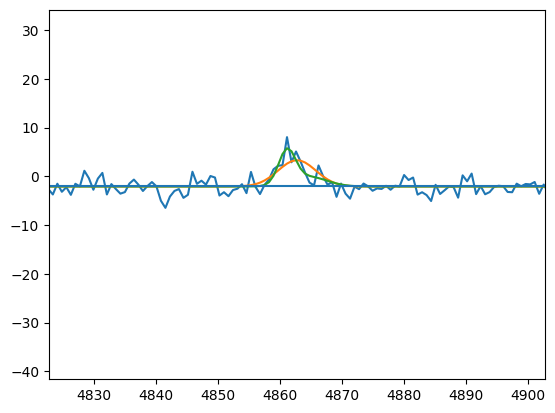

In [97]:
params_1comp, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit, conti_adjs = FIT.fit_multi_emission_vel(data_class=ALL_SPECTRA, id=test_id, two_component=False, w_dz=False)
model_1comp = np.sum([
    model_vel(lam, gaussian_parms=params_1comp['gaussian_params'][i]) for i in range(len(params_1comp['gaussian_params']))
], axis=0)

params_2comp, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit, conti_adjs = FIT.fit_multi_emission_vel(data_class=ALL_SPECTRA, id=test_id, two_component=True, w_dz=False)
model_2comp = np.sum([
    model_vel(lam, gaussian_parms=params_2comp['gaussian_params'][i]) for i in range(len(params_2comp['gaussian_params']))
], axis=0)

lam_mask = ((lam >= Hbeta_rest[0]-40) & (lam <= Hbeta_rest[0]-40+10)) | ((lam <= Hbeta_rest[0]+40) & (lam >= Hbeta_rest[0]+40-10))
plt.plot(lam, ALL_SPECTRA.flux[test_idx], label='Flux')
plt.plot(lam, model_1comp+conti_adjs[1], label='Model (1 component)')
plt.plot(lam, model_2comp+conti_adjs[1], label='Model (2 components)')
plt.axhline(conti_adjs[1])
plt.xlim((Hbeta_rest[0]-40, Hbeta_rest[0]+40))
plt.show()